# 🦍 Notebook 03 — Feature Engineering
Transform raw ecological variables into a clean, ML-ready feature matrix.

**Engineering steps:**
1. Age class encoding (biologically meaningful)
2. Group composition ratios (relative structure, not raw counts)
3. Dominance rank normalised within group-year
4. Rainfall seasonality index
5. Behavioural interaction terms
6. Imputation of missing observation-derived features
7. Final feature matrix export


## Cell 1 — Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import os, warnings

warnings.filterwarnings('ignore')
DATA_DIR = os.path.join('..', 'data')

df = pd.read_csv(os.path.join(DATA_DIR, 'analytical_dataset.csv'))
rain_df = pd.read_csv(os.path.join(DATA_DIR, 'rainfall_monthly.csv'))

print(f"Loaded analytical dataset: {df.shape}")
print(f"Columns: {list(df.columns)}")


Loaded analytical dataset: (4080, 30)
Columns: ['individual_id', 'group_id', 'group_name', 'year', 'age', 'sex', 'dominance_rank', 'forage_pct', 'rest_pct', 'social_pct', 'travel_pct', 'body_condition_score', 'survived_next_year', 'group_size', 'n_silverbacks', 'n_blackbacks', 'n_adult_females', 'n_juveniles', 'n_infants', 'multi_male_group', 'habitat_quality_score', 'annual_rainfall_mm', 'lagged_rainfall_mm', 'n_obs_sessions', 'mean_foraging_pct', 'mean_agonistic', 'mean_affiliation', 'mean_nn_dist_m', 'n_wet_sessions', 'n_dry_sessions']


## Cell 2 — Feature: Age Class (Biologically Grounded)

In [2]:
def assign_age_class(age):
    if age < 3:   return 'infant'
    if age < 8:   return 'juvenile'
    if age < 12:  return 'subadult'
    if age < 20:  return 'prime_adult'
    return 'senior'

df['age_class'] = df['age'].apply(assign_age_class)

# Ordinal encoding for ML (preserves biological order)
age_order = {'infant':0, 'juvenile':1, 'subadult':2, 'prime_adult':3, 'senior':4}
df['age_class_ord'] = df['age_class'].map(age_order)

print(df['age_class'].value_counts())
print("\n✅ age_class and age_class_ord created")


age_class
juvenile       1152
infant          879
prime_adult     752
subadult        661
senior          636
Name: count, dtype: int64

✅ age_class and age_class_ord created


## Cell 3 — Feature: Sex Encoding

In [3]:
df['sex_binary'] = (df['sex'] == 'M').astype(int)   # 1=Male, 0=Female
print("Sex distribution:")
print(df['sex'].value_counts())
print("\n✅ sex_binary created")


Sex distribution:
sex
F    2266
M    1814
Name: count, dtype: int64

✅ sex_binary created


## Cell 4 — Feature: Group Composition Ratios

In [4]:
# Proportional composition features are more informative than raw counts
# (a group of 5 with 2 silverbacks is very different from 20 with 2)

df['prop_silverbacks']  = df['n_silverbacks']  / df['group_size'].clip(lower=1)
df['prop_adult_females']= df['n_adult_females']/ df['group_size'].clip(lower=1)
df['prop_infants']      = df['n_infants']      / df['group_size'].clip(lower=1)
df['prop_juveniles']    = df['n_juveniles']    / df['group_size'].clip(lower=1)

# Dependency ratio: non-productive members per adult
df['dependency_ratio']  = (df['n_infants'] + df['n_juveniles']) /                            (df['n_adult_females'] + df['n_silverbacks'] + df['n_blackbacks']).clip(lower=1)

print("✅ Group composition ratios created:")
print(df[['prop_silverbacks','prop_adult_females','prop_infants','dependency_ratio']].describe().round(3))


✅ Group composition ratios created:
       prop_silverbacks  prop_adult_females  prop_infants  dependency_ratio
count          4080.000            4080.000      4080.000          4080.000
mean              0.140               0.417         0.166             0.668
std               0.128               0.066         0.072             0.287
min               0.053               0.200         0.000             0.000
25%               0.067               0.368         0.118             0.500
50%               0.105               0.421         0.167             0.636
75%               0.154               0.474         0.211             0.818
max               1.000               0.533         0.333             1.500


## Cell 5 — Feature: Within-Group Dominance Rank (Normalised)

In [5]:
# Raw dominance rank is not comparable across groups of different sizes
# Normalise to [0,1] within each group-year

df['dom_rank_norm'] = df.groupby(['group_id','year'])['dominance_rank'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

print("Normalised dominance rank (sample):")
print(df[['group_name','year','dominance_rank','dom_rank_norm']].head(8).to_string(index=False))
print("\n✅ dom_rank_norm created")


Normalised dominance rank (sample):
group_name  year  dominance_rank  dom_rank_norm
   Agashya  2010               2            0.2
   Agashya  2011               1            0.0
   Agashya  2012               1            0.0
   Agashya  2013               2            0.5
   Agashya  2014               1            0.0
   Agashya  2015               1            0.0
   Agashya  2016               1            0.0
   Agashya  2017               1            0.0

✅ dom_rank_norm created


## Cell 6 — Feature: Rainfall Seasonality Index

In [6]:
# Compute wet-season vs dry-season rainfall ratio per year
# Higher values → more concentrated wet season (feast-famine contrast)
wet_months = rain_df[rain_df['season']=='wet'].groupby('year')['monthly_rainfall_mm'].sum()
dry_months  = rain_df[rain_df['season']=='dry'].groupby('year')['monthly_rainfall_mm'].sum()
seasonality = (wet_months / (dry_months + 1)).rename('rainfall_seasonality_idx').reset_index()
seasonality.columns = ['year', 'rainfall_seasonality_idx']

df = df.merge(seasonality, on='year', how='left')

# Also: rainfall anomaly from long-run mean (z-score)
ann_rain = df.groupby('year')['annual_rainfall_mm'].first()
df['rainfall_anomaly_z'] = df['year'].map(
    (ann_rain - ann_rain.mean()) / ann_rain.std()
)

# Lagged rainfall z-score
lag_mean = df['lagged_rainfall_mm'].mean()
lag_std  = df['lagged_rainfall_mm'].std()
df['lagged_rain_z'] = (df['lagged_rainfall_mm'] - lag_mean) / lag_std

print("✅ Rainfall features created:")
print(df[['year','annual_rainfall_mm','lagged_rainfall_mm','rainfall_anomaly_z','lagged_rain_z']].drop_duplicates('year').head(8).to_string(index=False))


✅ Rainfall features created:
 year  annual_rainfall_mm  lagged_rainfall_mm  rainfall_anomaly_z  lagged_rain_z
 2010              1133.2                 NaN            0.221945            NaN
 2011               969.9              1133.2           -1.142429       0.249991
 2012              1035.6               969.9           -0.593504      -1.144158
 2013              1019.0              1035.6           -0.732198      -0.583254
 2014              1061.7              1019.0           -0.375439      -0.724974
 2015              1342.4              1061.7            1.969814      -0.360429
 2016              1384.6              1342.4            2.322396       2.036005
 2017              1041.6              1384.6           -0.543374       2.396281


## Cell 7 — Feature: Behavioural Indices

In [7]:
# Social integration index: affiliation relative to agonistic events
# High values → more affiliative = better social integration
df['social_integration'] = df['mean_affiliation'] / (df['mean_agonistic'] + 1)

# Foraging efficiency proxy: foraging% * body condition
df['foraging_efficiency'] = df['forage_pct'] * df['body_condition_score'] / 100

# Cohesion index: inverse of mean nearest-neighbour distance
# (closer neighbours → tighter group → better protection)
df['cohesion_idx'] = 1 / (df['mean_nn_dist_m'] + 1)

print("✅ Behavioural features created:")
print(df[['social_integration','foraging_efficiency','cohesion_idx']].describe().round(3))


✅ Behavioural features created:
       social_integration  foraging_efficiency  cohesion_idx
count            2448.000             4080.000      2448.000
mean                1.213                1.444         0.134
std                 0.824                0.389         0.065
min                 0.000                0.410         0.035
25%                 0.500                1.166         0.090
50%                 1.088                1.420         0.119
75%                 1.752                1.686         0.158
max                 5.000                3.543         0.667


## Cell 8 — Impute Missing Observation-Derived Features

In [8]:
obs_features = ['n_obs_sessions','mean_foraging_pct','mean_agonistic',
                'mean_affiliation','mean_nn_dist_m','n_wet_sessions','n_dry_sessions',
                'social_integration','foraging_efficiency','cohesion_idx']

missing_pct = (df[obs_features].isnull().sum() / len(df) * 100).round(1)
print("Missing % in observation features:")
print(missing_pct.to_string())

# Median imputation (robust to outliers)
imputer = SimpleImputer(strategy='median')
df[obs_features] = imputer.fit_transform(df[obs_features])

print(f"\n✅ Imputed {(missing_pct > 0).sum()} features using median strategy")
print(f"   Remaining nulls: {df[obs_features].isnull().sum().sum()}")


Missing % in observation features:
n_obs_sessions         40.0
mean_foraging_pct      40.0
mean_agonistic         40.0
mean_affiliation       40.0
mean_nn_dist_m         40.0
n_wet_sessions         40.0
n_dry_sessions         40.0
social_integration     40.0
foraging_efficiency     0.0
cohesion_idx           40.0

✅ Imputed 9 features using median strategy
   Remaining nulls: 0


## Cell 9 — Assemble Final Feature Matrix

In [9]:
# Define final feature set for ML
FEATURES = [
    # Demographic
    'age', 'age_class_ord', 'sex_binary',
    # Group structure
    'group_size', 'n_silverbacks', 'multi_male_group',
    'prop_silverbacks', 'prop_adult_females', 'prop_infants',
    'dependency_ratio', 'habitat_quality_score',
    # Individual status
    'dom_rank_norm', 'body_condition_score',
    # Behaviour
    'forage_pct', 'rest_pct', 'social_pct', 'travel_pct',
    'mean_foraging_pct', 'mean_agonistic', 'mean_affiliation',
    'social_integration', 'foraging_efficiency', 'cohesion_idx',
    # Environment
    'annual_rainfall_mm', 'lagged_rainfall_mm',
    'rainfall_anomaly_z', 'lagged_rain_z', 'rainfall_seasonality_idx',
]

TARGET = 'survived_next_year'

# Verify all features exist
missing_cols = [f for f in FEATURES if f not in df.columns]
if missing_cols:
    print(f"⚠️  Missing columns: {missing_cols}")
else:
    print(f"✅ All {len(FEATURES)} features present")

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"\nFeature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print(f"\nClass distribution:")
print(f"  Survived (1)  : {y.sum()} ({y.mean()*100:.1f}%)")
print(f"  Did not  (0)  : {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# Save feature matrix
feat_df = X.copy()
feat_df[TARGET] = y
feat_df['individual_id'] = df['individual_id']
feat_df['year']          = df['year']
feat_df['group_name']    = df['group_name']
feat_df['age_class']     = df['age_class']
feat_df['sex']           = df['sex']
feat_df.to_csv(os.path.join(DATA_DIR, 'feature_matrix.csv'), index=False)
print("\n✅ Saved: feature_matrix.csv")


✅ All 28 features present

Feature matrix X : (4080, 28)
Target vector  y : (4080,)

Class distribution:
  Survived (1)  : 4007 (98.2%)
  Did not  (0)  : 73 (1.8%)

✅ Saved: feature_matrix.csv


## Cell 10 — Feature Distribution Visualisation

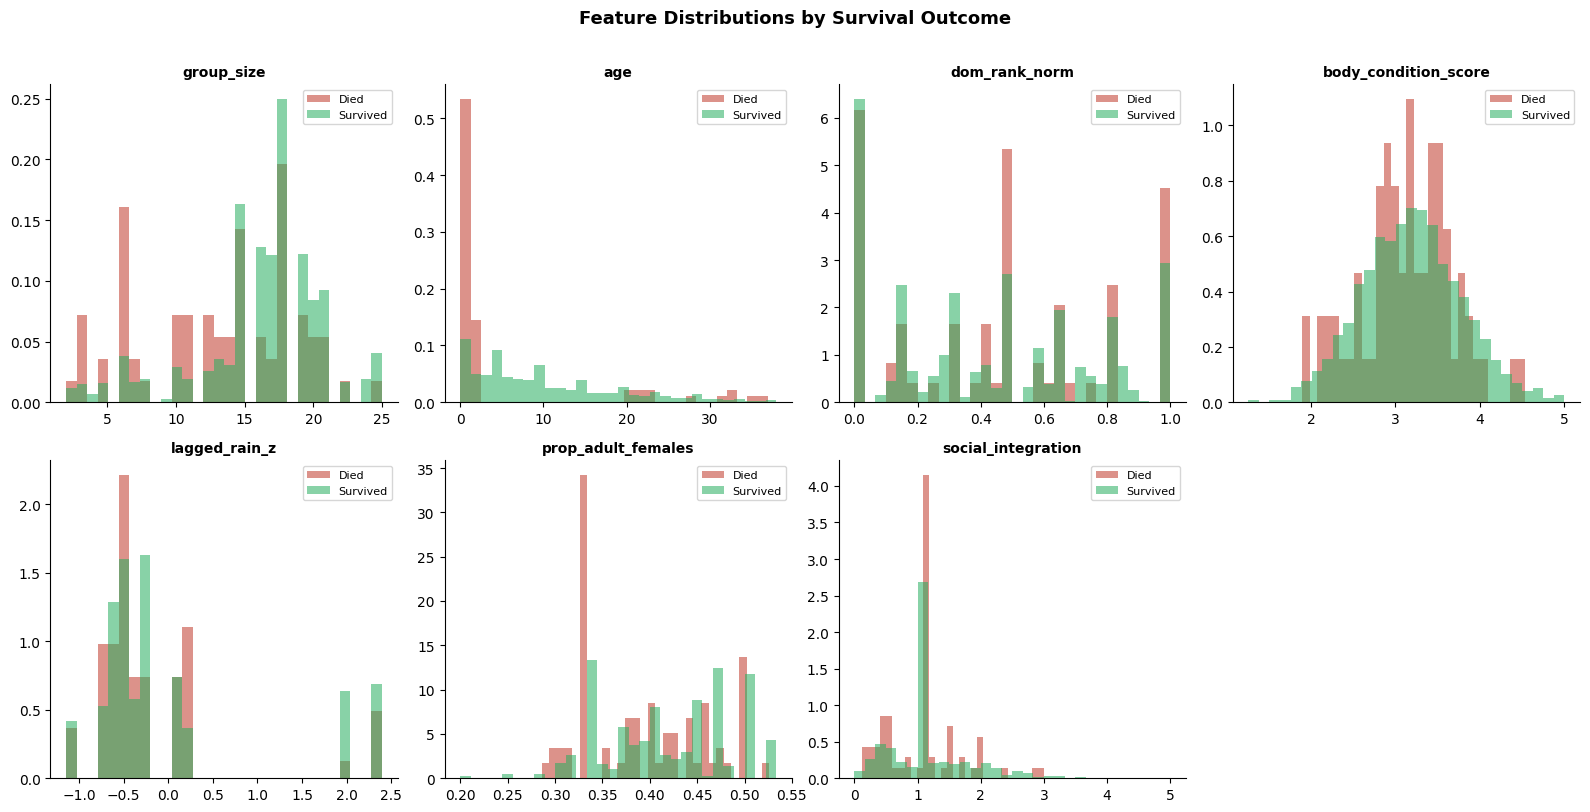


✅ Notebook 03 complete. Proceed to 04_modeling.ipynb


In [10]:
key_features = ['group_size','age','dom_rank_norm','body_condition_score',
                'lagged_rain_z','prop_adult_females','social_integration']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color in [(0,'#c0392b'), (1,'#27ae60')]:
        vals = df[df[TARGET]==label][feat].dropna()
        axes[i].hist(vals, bins=30, alpha=0.55, color=color,
                     label='Died' if label==0 else 'Survived', density=True)
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
    for spine in ['top','right']: axes[i].spines[spine].set_visible(False)

axes[-1].axis('off')

fig.suptitle('Feature Distributions by Survival Outcome', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join('..','data','03_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Notebook 03 complete. Proceed to 04_modeling.ipynb")
